# Lab assignment №1, part 2

This lab assignment consists of several parts. You are supposed to make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

__*This is the second part of the assignment. First and third parts are waiting for you in the same directory.*__

## Part 2. Data preprocessing, model training and evaluation.

### 1. Reading the data
Today we work with the [dataset](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Vehicle+Silhouettes%29), describing different cars for multiclass ($k=4$) classification problem. The data is available below.

In [ ]:
! pip install scipy==1.11.4
#import scipy
from scipy import interp
! pip install scikit-plot
#print(scipy.__version__)

In [ ]:
# If on colab, uncomment the following lines

! wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_made/homeworks/lab01_ml_pipeline/car_data.csv

--2024-10-27 09:45:30--  https://raw.githubusercontent.com/girafe-ai/ml-course/22f_made/homeworks/lab01_ml_pipeline/car_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58374 (57K) [text/plain]
Saving to: ‘car_data.csv’

car_data.csv        100%[===================>]  57.01K  --.-KB/s    in 0.01s   

2024-10-27 09:45:30 (5.28 MB/s) - ‘car_data.csv’ saved [58374/58374]



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

dataset = pd.read_csv('car_data.csv', delimiter=',', header=None).values
data = dataset[:, :-1].astype(int)
target = dataset[:, -1]

print(data.shape, target.shape)

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.35, random_state=42)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)



(846, 19) (846,)
(549, 19) (549,) (297, 19) (297,)


To get some insights about the dataset, `pandas` might be used. The `train` part is transformed to `pd.DataFrame` below.

In [ ]:
X_train_pd = pd.DataFrame(X_train)

# First 15 rows of our dataset.
X_train_pd.head(15)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,822,95,41,82,170,65,9,145,46,19,145,163,314,140,64,4,8,199,207
1,486,104,57,103,222,72,12,221,30,25,177,223,718,218,72,11,12,186,195
2,182,91,42,66,169,66,7,145,44,19,140,169,325,159,67,4,0,201,207
3,375,109,52,95,189,58,4,227,29,25,158,262,776,217,82,0,19,187,186
4,528,95,47,73,195,70,7,167,38,20,152,184,430,185,69,9,19,200,206
5,223,81,44,72,139,60,6,153,44,19,146,180,347,178,81,1,15,182,186
6,840,93,34,66,140,56,7,130,51,18,120,151,251,114,62,5,29,201,207
7,593,89,43,77,147,54,8,144,46,19,146,163,308,174,64,13,5,194,201
8,346,117,52,110,228,65,12,212,31,24,163,228,668,220,66,21,25,194,205
9,357,109,49,109,193,59,10,207,32,24,156,225,635,213,70,13,31,191,202


Methods `describe` and `info` deliver some useful information.

In [ ]:
X_train_pd.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,425.723133,93.520947,44.675774,81.801457,168.204007,61.644809,8.457195,167.327869,41.273224,20.468124,147.438980,186.734062,431.540984,173.763206,72.158470,6.522769,12.646630,188.998179,195.854281
std,242.288797,8.063277,6.154680,15.928751,33.047995,7.110666,3.945857,32.506680,7.777590,2.526030,14.631309,30.436279,171.479332,31.793047,7.335198,4.980796,8.833356,6.298389,7.449629
min,0.000000,76.000000,33.000000,42.000000,104.000000,47.000000,2.000000,114.000000,26.000000,17.000000,118.000000,131.000000,191.000000,112.000000,59.000000,0.000000,0.000000,176.000000,181.000000
25%,217.000000,87.000000,40.000000,70.000000,140.000000,57.000000,7.000000,146.000000,34.000000,19.000000,136.000000,167.000000,317.000000,148.000000,67.000000,2.000000,6.000000,184.000000,191.000000
50%,430.000000,93.000000,44.000000,79.000000,165.000000,61.000000,8.000000,157.000000,43.000000,20.000000,145.000000,177.000000,363.000000,173.000000,71.000000,6.000000,11.000000,189.000000,197.000000
75%,636.000000,99.000000,49.000000,98.000000,195.000000,66.000000,10.000000,196.000000,46.000000,23.000000,159.000000,216.000000,576.000000,196.000000,75.000000,10.000000,19.000000,193.000000,201.000000
max,845.000000,117.000000,59.000000,110.000000,306.000000,126.000000,52.000000,265.000000,59.000000,29.000000,186.000000,288.000000,1018.000000,268.000000,127.000000,22.000000,40.000000,206.000000,211.000000


In [ ]:
X_train_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       549 non-null    int64
 1   1       549 non-null    int64
 2   2       549 non-null    int64
 3   3       549 non-null    int64
 4   4       549 non-null    int64
 5   5       549 non-null    int64
 6   6       549 non-null    int64
 7   7       549 non-null    int64
 8   8       549 non-null    int64
 9   9       549 non-null    int64
 10  10      549 non-null    int64
 11  11      549 non-null    int64
 12  12      549 non-null    int64
 13  13      549 non-null    int64
 14  14      549 non-null    int64
 15  15      549 non-null    int64
 16  16      549 non-null    int64
 17  17      549 non-null    int64
 18  18      549 non-null    int64
dtypes: int64(19)
memory usage: 81.6 KB


### 2. Machine Learning pipeline
Here you are supposed to perform the desired transformations. Please, explain your results briefly after each task.

#### 2.0. Data preprocessing
* Make some transformations of the dataset (if necessary). Briefly explain the transformations

In [ ]:
### YOUR CODE HERE
# Заполнение пропусков не требуется, так как их нет (следует из предыдущего блока)
# В первой колонке находится идентификатор наблюдения - его нужно удалить:
X_test_pd = pd.DataFrame(X_test)
X_train = X_train_pd.drop(columns=[0])
X_test = X_test_pd.drop(columns=[0])

# Нормализация признаков - необходимое условие регрессионного анализа, это позволит гарантировать одинаковый вклад различных признаков в модель.
# Нормализацию тестовой и обучающей выборки нужно проводить по отдельности
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 2.1. Basic logistic regression
* Find optimal hyperparameters for logistic regression with cross-validation on the `train` data (small grid/random search is enough, no need to find the *best* parameters).

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` `tol=1e-3` and ` max_iter=500`.*

In [ ]:
### YOUR CODE HERE
from scipy.stats import uniform
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score
import scikitplot
import matplotlib.pyplot as plt

In [ ]:
param_grid = {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2']}

import warnings
#param_grid = dict(C=uniform(loc=0, scale=100), penalty=['l1', 'l2'])
log_reg = LogisticRegression(multi_class='multinomial', solver='saga', tol=1e-3, max_iter=500, random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy')
    #grid_search = RandomizedSearchCV(log_reg, param_distributions=param_grid, n_iter=100, cv=10)
    grid_search.fit(X_train_scaled, y_train)

best_params = grid_search.best_params_

print('Оптимальные гиперпараметры:', best_params)

Оптимальные гиперпараметры: {'C': 1, 'penalty': 'l1'}


In [ ]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    model = LogisticRegression(**best_params, multi_class='multinomial', solver='saga', tol=1e-3, max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1:', f1_score(y_test, y_pred, average='weighted'))


Accuracy: 0.8148148148148148
F1: 0.811074572017333


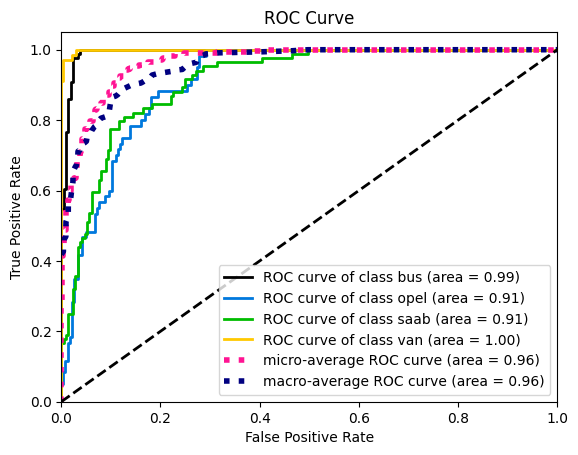

In [ ]:
scikitplot.metrics.plot_roc(y_test, y_proba)
plt.title('ROC Curve')
plt.show()

In [ ]:
# You might use this command to install scikit-plot.
# Warning, if you a running locally, don't call pip from within jupyter, call it from terminal in the corresponding
# virtual environment instead

# ! pip install scikit-plot

#### 2.2. PCA: explained variance plot
* Apply the PCA to the train part of the data. Build the explaided variance plot.

In [ ]:
### YOUR CODE HERE
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_train_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

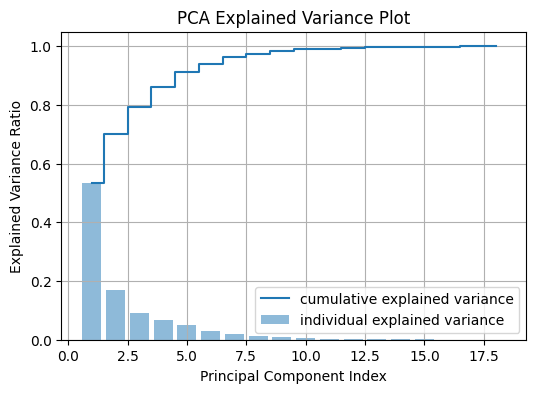

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='cumulative explained variance')

plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance Plot')
plt.legend(loc='best')
plt.grid(True)
plt.show()

#### 2.3. PCA trasformation
* Select the appropriate number of components. Briefly explain your choice. Should you normalize the data?

*Use `fit` and `transform` methods to transform the `train` and `test` parts.*

In [ ]:
### YOUR CODE HERE
# Мы выбрали 10 компонент на основе объясненной дисперсии
# потому что на графике видно, что 10 компонент объясняют более 95% общей дисперсии
n_components = 10

pca = PCA(n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('Форма X_train после PCA:', X_train_pca.shape)
print('Форма X_test после PCA:', X_test_pca.shape)

Форма X_train после PCA: (549, 10)
Форма X_test после PCA: (297, 10)


Нормализовывать данные нужно, так как масштаб влияет на результативность PCА, т.к. PCA может дать непропорционально большое значение тем признакам, которые имеют больший разброс. Для нормализации чаще всего используется приведение каждого признака к распределению с нулевым средним и единичной дисперсией (что было сделано ранее).

**Note: From this point `sklearn` [Pipeline](https://scikit-learn.org/stable/modules/compose.html) might be useful to perform transformations on the data. Refer to the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) for more information.**

#### 2.4. Logistic regression on PCA-preprocessed data.
* Find optimal hyperparameters for logistic regression with cross-validation on the transformed by PCA `train` data.

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` and `tol=1e-3`*

F1: 0.8079038172666944
Accuracy: 0.8114478114478114


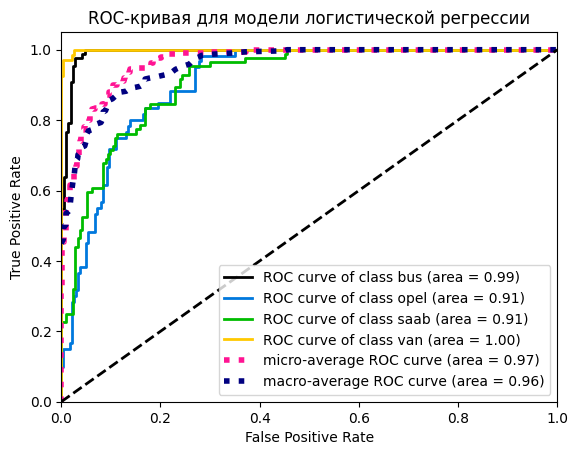

In [ ]:
### YOUR CODE HERE
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('logreg', LogisticRegression(multi_class='multinomial', solver='saga', tol=1e-3, max_iter=500, random_state=42))
])

param_grid = {'pca__n_components': [5, 10, 15], 'logreg__C': [0.1, 1, 10]}

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    grid_search = GridSearchCV(pipeline, param_grid, cv=5)
    grid_search.fit(X_train, y_train)

y_pred = grid_search.predict(X_test)
y_proba = grid_search.predict_proba(X_test)

f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

print('F1:', f1)
print('Accuracy:', accuracy)

scikitplot.metrics.plot_roc(y_test, y_proba)
plt.title('ROC-кривая для модели логистической регрессии')
plt.show()

Модель логистической регрессии согласно построенной ROC-кривой демонстрирует высокое качество предсказания классов - площадь под кривой для всех классов 0.9-1.0.

#### 2.5. Decision tree
* Now train a desicion tree on the same data. Find optimal tree depth (`max_depth`) using cross-validation.

* Measure the model quality using the same metrics you used above.

Лучшие параметры для дерева решений: {'decision_tree__max_depth': 10, 'pca__n_components': 15}
F1: 0.6556395945197795
Accuracy: 0.6531986531986532


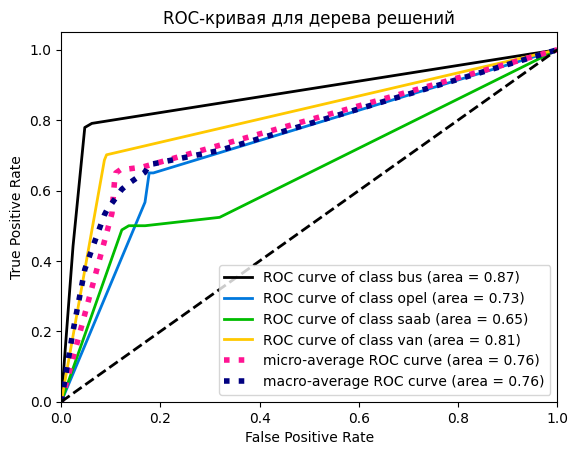

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# YOUR CODE HERE
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('decision_tree', DecisionTreeClassifier(random_state=42))
])

param_grid = {
    'decision_tree__max_depth': [5, 10, 15, 20, None],
    'pca__n_components': [5, 10, 15],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print('Лучшие параметры для дерева решений:', best_params)

y_pred = grid_search.predict(X_test)
y_proba = grid_search.predict_proba(X_test)

f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

print('F1:', f1)
print('Accuracy:', accuracy)

scikitplot.metrics.plot_roc(y_test, y_proba)
plt.title('ROC-кривая для дерева решений')
plt.show()

Дерево решенией согласно построенной ROC-кривой демонстрирует качество предсказания классов ощутимо хуже логистической кривой - площадь под кривой 0.65-0.87, однако ни для какого класса она не меньше 0.5, значит нет случайного классификатора.

#### 2.6. Bagging.
Here starts the ensembling part.

First we will use the __Bagging__ approach. Build an ensemble of $N$ algorithms varying N from $N_{min}=2$ to $N_{max}=100$ (with step 5).

We will build two ensembles: of logistic regressions and of decision trees.

*Comment: each ensemble should be constructed from models of the same family, so logistic regressions should not be mixed up with decision trees.*


*Hint 1: To build a __Bagging__ ensebmle varying the ensemble size efficiently you might generate $N_{max}$ subsets of `train` data (of the same size as the original dataset) using bootstrap procedure once. Then you train a new instance of logistic regression/decision tree with optimal hyperparameters you estimated before on each subset (so you train it from scratch). Finally, to get an ensemble of $N$ models you average the $N$ out of $N_{max}$ models predictions.*

*Hint 2: sklearn might help you with this taks. Some appropriate function/class might be out there.*

* Plot `f1` and `accuracy` scores plots w.r.t. the size of the ensemble.

* Briefly analyse the plot. What is the optimal number of algorithms? Explain your answer.

* How do you think, are the hyperparameters for the decision trees you found in 2.5 optimal for trees used in ensemble?

In [ ]:
# YOUR CODE HERE
from sklearn.ensemble import BaggingClassifier

ensemble_sizes = range(2, 101, 5)

def evaluate_ensemble(model_class, model_params, X_train, y_train, X_test, y_test):
    f1_scores = []
    accuracy_scores = []
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for n_estimators in ensemble_sizes:
            model = BaggingClassifier(
                estimator=model_class(**model_params),
                n_estimators=n_estimators,
                bootstrap=True,
                random_state=42
            )
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            accuracy = accuracy_score(y_test, y_pred)

            f1_scores.append(f1)
            accuracy_scores.append(accuracy)

        return f1_scores, accuracy_scores

In [ ]:
log_reg_params = {'C': 1,'penalty': 'l1','solver': 'saga', 'max_iter': 500, 'multi_class': 'multinomial', 'tol': 1e-3, 'random_state': 42}
f1_scores_lr, accuracy_scores_lr = evaluate_ensemble(LogisticRegression, log_reg_params, X_train_scaled, y_train, X_test_scaled, y_test)
decision_tree_params = {'max_depth': 15,  'random_state': 42}
f1_scores_dt, accuracy_scores_dt = evaluate_ensemble(DecisionTreeClassifier, decision_tree_params, X_train_scaled, y_train, X_test_scaled, y_test)

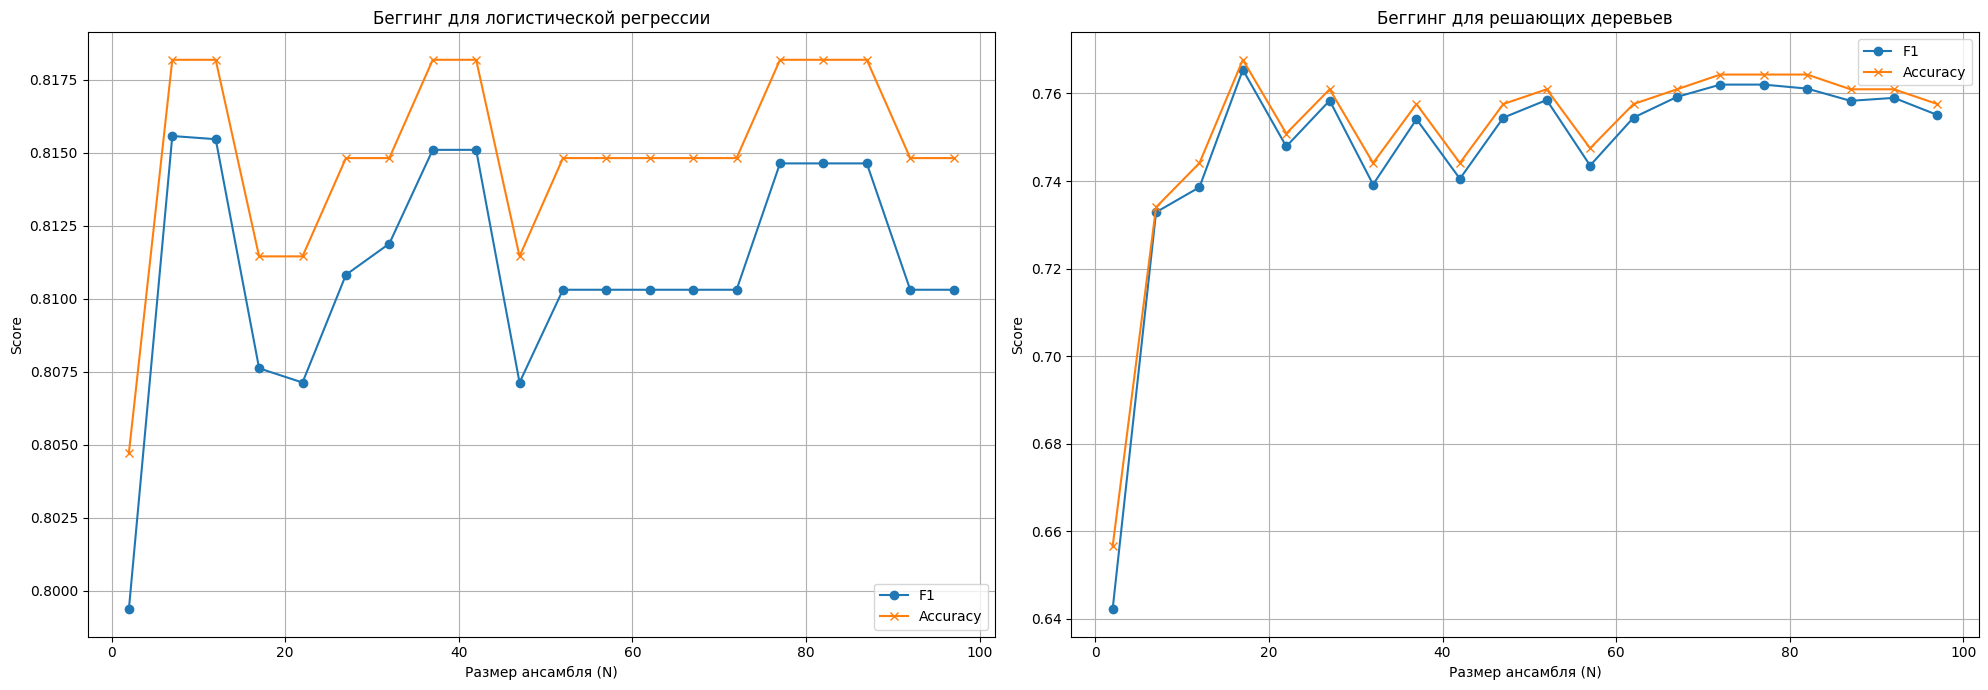

Оптимальный размер ансамбля для:
логистической регрессии -  7
дерева решений -  17


In [ ]:
plt.figure(figsize=(20, 7))
plt.subplot(1, 2, 1)
plt.plot(ensemble_sizes, f1_scores_lr, label='F1', marker='o')
plt.plot(ensemble_sizes, accuracy_scores_lr, label='Accuracy', marker='x')
plt.title('Беггинг для логистической регрессии')
plt.xlabel('Размер ансамбля (N)')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ensemble_sizes, f1_scores_dt, label='F1', marker='o')
plt.plot(ensemble_sizes, accuracy_scores_dt, label='Accuracy', marker='x')
plt.title('Беггинг для решающих деревьев')
plt.xlabel('Размер ансамбля (N)')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

optimal_lr_size = ensemble_sizes[np.argmax(f1_scores_lr)]
optimal_tree_size = ensemble_sizes[np.argmax(f1_scores_dt)]

print('Оптимальный размер ансамбля для:')
print('логистической регрессии - ', optimal_lr_size)
print('дерева решений - ', optimal_tree_size)

Для логистической регрессии оптимальный ансамбль имеет размер 7, а для решающих деревьев - 17. Больший размер ансамбя для обеих моделей не ведет к увеличению метрик качества. Следует отметить, что метрики качества для ансамбля логистической регрессии выше таковых для ансамбля решающих деревьев.
Гиперпараметры, установленные на этапе 2.5, показали хорошие результаты, что подтверждается высоким значением метрик. Однако, стоит проверить влияние других значений, так как это может помочь избежать переобучения.

#### 2.7. Random Forest
Now we will work with the Random Forest (its `sklearn` implementation).

* * Plot `f1` and `accuracy` scores plots w.r.t. the number of trees in Random Forest.

* What is the optimal number of trees you've got? Is it different from the optimal number of logistic regressions/decision trees in 2.6? Explain the results briefly.

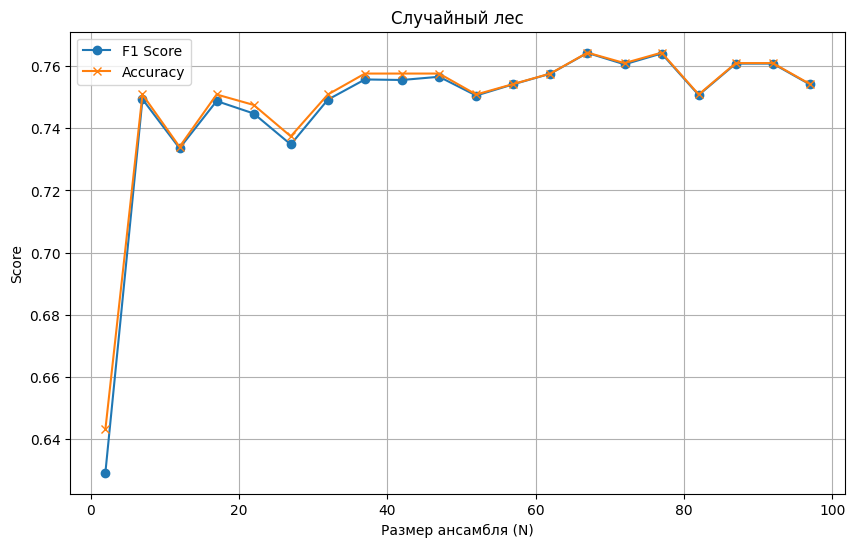

Оптимальный размер ансамбля для случайного леса: 67


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# YOUR CODE HERE
ensemble_sizes = range(2, 101, 5)

def evaluate_random_forest (X_train, y_train, X_test, y_test):
    f1_scores = []
    accuracy_scores = []
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for n_estimators in ensemble_sizes:
            model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            accuracy = accuracy_score(y_test, y_pred)

            f1_scores.append(f1)
            accuracy_scores.append(accuracy)

        return f1_scores, accuracy_scores

f1_scores, accuracy_scores = evaluate_random_forest(X_train_scaled, y_train, X_test_scaled, y_test)

plt.figure(figsize=(10, 6))
plt.plot(ensemble_sizes, f1_scores, label='F1 Score', marker='o')
plt.plot(ensemble_sizes, accuracy_scores, label='Accuracy', marker='x')
plt.title('Случайный лес')
plt.xlabel('Размер ансамбля (N)')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

optimal_rt_size = ensemble_sizes[np.argmax(f1_scores)]

print('Оптимальный размер ансамбля для случайного леса:', optimal_rt_size)


Оптимальный размер ансамбля для случайного леса - 67, что больше, чем ансамбль логистической регрессии и ансамбль из решающих деревьев. Следует отметить, что зависимость метрик качества от размера случайного леса более стабильна, чем аналогичная зависимость для логистической регрессии и решающих деревьев.

#### 2.8. Learning curve
Your goal is to estimate, how does the model behaviour change with the increase of the `train` dataset size.

* Split the training data into 10 equal (almost) parts. Then train the models from above (Logistic regression, Desicion Tree, Random Forest) with optimal hyperparameters you have selected on 1 part, 2 parts (combined, so the train size in increased by 2 times), 3 parts and so on.

* Build a plot of `accuracy` and `f1` scores on `test` part, varying the `train` dataset size (so the axes will be score - dataset size.

* Analyse the final plot. Can you make any conlusions using it?

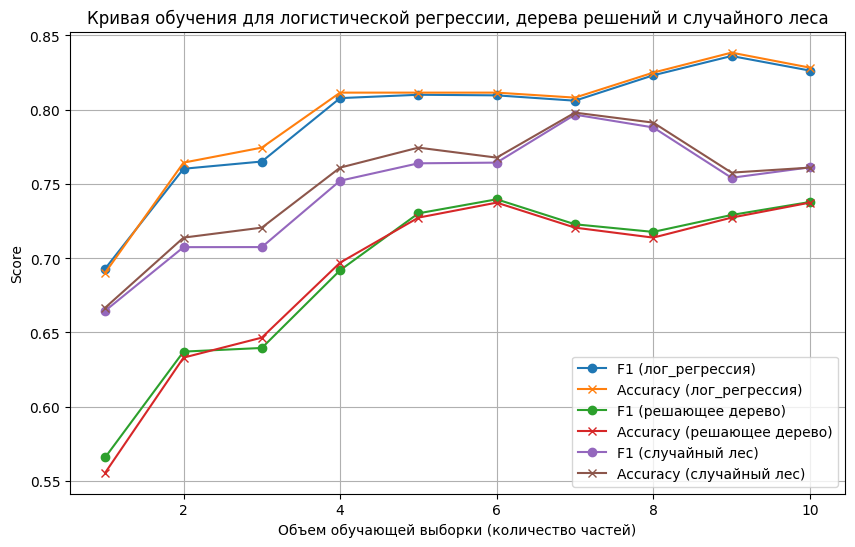

In [ ]:
def evaluate_learning_curve(model_class, model_params, X_train, y_train, X_test, y_test):

    X_parts = np.array_split(X_train, 10)
    y_parts = np.array_split(y_train, 10)

    f1_scores = []
    accuracy_scores = []
    train_sizes = []
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for i in range(1, 11):
            X_train_subset = np.concatenate(X_parts[:i])
            y_train_subset = np.concatenate(y_parts[:i])

            model = model_class(**model_params)
            model.fit(X_train_subset, y_train_subset)

            y_pred = model.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')
            accuracy = accuracy_score(y_test, y_pred)

            f1_scores.append(f1)
            accuracy_scores.append(accuracy)
            #train_sizes.append(len(X_train_subset))
            train_sizes.append(i)
    return train_sizes, f1_scores, accuracy_scores

log_reg_params = {'C': 10, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 500, 'multi_class': 'multinomial', 'tol': 1e-3, 'random_state': 42}
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(**log_reg_params))
])
decision_tree_params = {'max_depth': 15, 'random_state': 42}
random_forest_params = {'n_estimators': 100, 'max_depth': 15, 'random_state': 42}

train_sizes_lr, f1_scores_lr, accuracy_scores_lr = evaluate_learning_curve(LogisticRegression, log_reg_params, X_train_scaled, y_train, X_test_scaled, y_test)
train_sizes_dt, f1_scores_dt, accuracy_scores_dt = evaluate_learning_curve(DecisionTreeClassifier, decision_tree_params, X_train_scaled, y_train, X_test_scaled, y_test)
train_sizes_rf, f1_scores_rf, accuracy_scores_rf = evaluate_learning_curve(RandomForestClassifier, random_forest_params, X_train_scaled, y_train, X_test_scaled, y_test)


plt.figure(figsize=(10, 6))

plt.plot(train_sizes_lr, f1_scores_lr, label='F1 (лог_регрессия)', marker='o')
plt.plot(train_sizes_lr, accuracy_scores_lr, label='Accuracy (лог_регрессия)', marker='x')
plt.plot(train_sizes_dt, f1_scores_dt, label='F1 (решающее дерево)', marker='o')
plt.plot(train_sizes_dt, accuracy_scores_dt, label='Accuracy (решающее дерево)', marker='x')
plt.plot(train_sizes_rf, f1_scores_rf, label='F1 (случайный лес)', marker='o')
plt.plot(train_sizes_rf, accuracy_scores_rf, label='Accuracy (случайный лес)', marker='x')

plt.title('Кривая обучения для логистической регрессии, дерева решений и случайного леса')
#plt.xlabel('Объем обучающей выборки')
plt.xlabel('Объем обучающей выборки (количество частей)')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()


**Analyse the final plot. Can you make any conlusions using it?**

Из построенных графиков видно, что чем больше данных использовано для обучения, тем выше метрики качества. Вначале наблюдается более быстрый рост, затем более медленный и выход на плато. Логистическая регрессия медленнее улучшает свои показатели, чем случайный лес. Решающие деревья занчительно уступают случайному лесу и логистической регрессии.

#### 2.9. Boosting
Your goal is to build a boosting ensemble using xgboost, CatBoost or lightgbm package.
Please, do not use the sklearn API for these models.

Find optimal number of decision trees in the boosting ensembe using grid search or other methods.
Please, explain your answer.

Оптимальные параметры: {'learning_rate': 0.4, 'max_depth': 5, 'n_estimators': 700}
Accuracy на тестовой выборке: 0.7609427609427609
F1 на тестовой выборке: 0.761970397151829


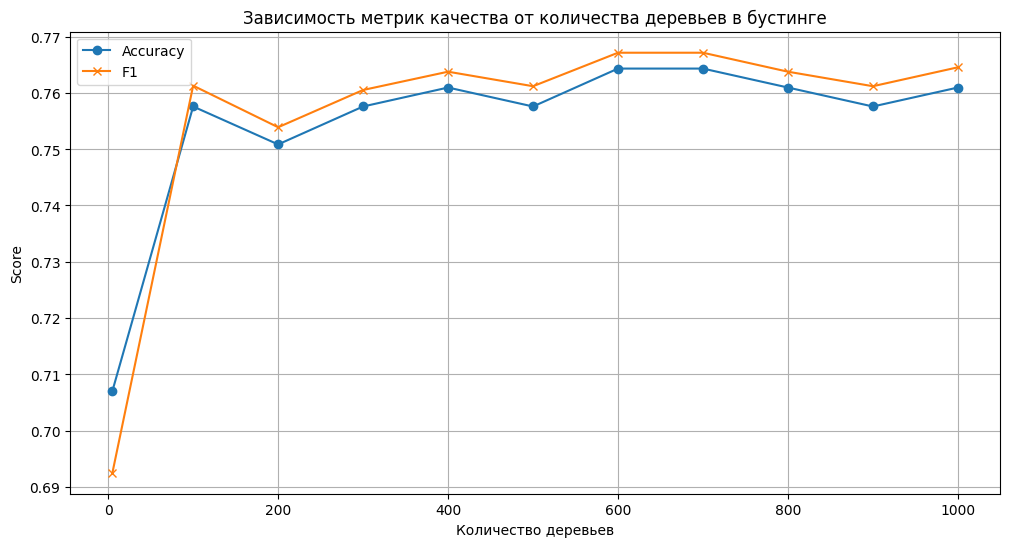

In [ ]:
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

param_grid = {
    'n_estimators': [5, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.3, 0.4, 0.5]
}

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss",random_state=42)
grid_search = GridSearchCV(xgb_model, param_grid, scoring='accuracy',  refit='accuracy',cv=5,n_jobs=-1)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    grid_search.fit(X_train, y_train_encoded)

print('Оптимальные параметры:', grid_search.best_params_)

best_xgb_model = grid_search.best_estimator_
y_pred = best_xgb_model.predict(X_test)
y_pred_proba = best_xgb_model.predict_proba(X_test)

accuracy = accuracy_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred, average='weighted')
print('Accuracy на тестовой выборке:', accuracy)
print('F1 на тестовой выборке:', f1)

f1_scores = []
accuracy_scores = []

# best_params = grid_search.best_params_
# del best_params['n_estimators']

# for n_estimators in param_grid['n_estimators']:
#     xgb_model.set_params(n_estimators, **best_params)
#     with warnings.catch_warnings():
#         warnings.simplefilter('ignore')
#         xgb_model.fit(X_train, y_train_encoded)

#         y_pred = xgb_model.predict(X_test)
#         f1 = f1_score(y_test_encoded, y_pred, average='weighted')
#         accuracy = accuracy_score(y_test_encoded, y_pred)

#         f1_scores.append(f1)
#         accuracy_scores.append(accuracy)

for params in grid_search.cv_results_['params']:
    xgb_model.set_params(**params)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        xgb_model.fit(X_train, y_train_encoded)
        y_pred = xgb_model.predict(X_test)
        f1 = f1_score(y_test_encoded, y_pred, average='weighted')
        accuracy = accuracy_score(y_test_encoded, y_pred)
        f1_scores.append(f1)
        accuracy_scores.append(accuracy)


plt.figure(figsize=(12, 6))
plt.plot(param_grid['n_estimators'], accuracy_scores[:len(param_grid['n_estimators'])], marker='o', label='Accuracy')
plt.plot(param_grid['n_estimators'], f1_scores[:len(param_grid['n_estimators'])], marker='x', label='F1')
plt.xlabel('Количество деревьев' )
plt.ylabel('Score')
plt.title('Зависимость метрик качества от количества деревьев в бустинге')
plt.legend()
plt.grid(True)
plt.show()



Сначала наблюдается резкий рост качества классификации до 100 деревьев, потом более плавный до 600 деревьев, затем - выход на плато и падение, что может свидетельствовать о наступлении переобучения. Оптимальное количество деревьев - 600.